In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/marketing_data.csv', parse_dates=['date'])

print("Shape:", df.shape)
print("\nColumn types:")
print(df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Importing plotly failed. Interactive plots will not work.


Shape: (1827, 6)

Column types:
date               datetime64[us]
search_interest           float64
sessions                    int64
conversion_rate           float64
revenue                   float64
channel                       str
dtype: object

First 3 rows:


,date,search_interest,sessions,conversion_rate,revenue,channel
0,2020-01-01,80.6,18236,0.0348,43537.55,Direct
1,2020-01-02,79.1,17456,0.0352,40346.21,Organic
2,2020-01-03,80.6,17679,0.0342,39478.33,Organic


In [2]:
prophet_df = df[['date', 'sessions']].rename(columns={
    'date': 'ds',
    'sessions': 'y'
})

print("Columns:", prophet_df.columns.tolist())
print("Shape:", prophet_df.shape)
print("\nFirst 3 rows:")
prophet_df.head(3)

Columns: ['ds', 'y']
Shape: (1827, 2)

First 3 rows:


,ds,y
0,2020-01-01,18236
1,2020-01-02,17456
2,2020-01-03,17679


In [3]:
model = Prophet(
    interval_width=0.95,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

model.fit(prophet_df)

print("Model fitted successfully.")
print("Seasonalities loaded:", list(model.seasonalities.keys()))

12:42:00 - cmdstanpy - INFO - Chain [1] start processing
12:42:01 - cmdstanpy - INFO - Chain [1] done processing


Model fitted successfully.
Seasonalities loaded: ['yearly', 'weekly']


In [4]:
future = model.make_future_dataframe(periods=0)

forecast = model.predict(future)

print("Forecast shape:", forecast.shape)
print("\nKey columns:")
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5))

Forecast shape: (1827, 19)

Key columns:
             ds          yhat    yhat_lower    yhat_upper
1822 2024-12-27  17871.927217  13504.052094  22124.789366
1823 2024-12-28  18369.241256  14190.767155  22620.789441
1824 2024-12-29  18371.149999  14011.020868  22494.288508
1825 2024-12-30  17906.012118  13652.303688  22122.683418
1826 2024-12-31  17757.107820  13717.101454  22261.926036


In [5]:
results = forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].copy()
results['actual'] = df['sessions'].values

results['anomaly'] = (
    (results['actual'] < results['yhat_lower']) |
    (results['actual'] > results['yhat_upper'])
)

results['deviation'] = results['actual'] - results['yhat']

anomalies = results[results['anomaly'] == True].copy()

print(f"Total days analysed: {len(results)}")
print(f"Anomalies detected: {len(anomalies)}")
print(f"\nAnomaly dates:")
print(anomalies[['ds', 'actual', 'yhat', 'deviation']].to_string(index=False))

Total days analysed: 1827
Anomalies detected: 25

Anomaly dates:
        ds  actual         yhat    deviation
2022-06-10    5518 12499.695063 -6981.695063
2022-06-11    5867 12870.275291 -7003.275291
2022-06-12    6183 12756.915993 -6573.915993
2022-06-13    5649 12190.881872 -6541.881872
2022-06-14    5490 11958.059901 -6468.059901
2022-06-15    5826 11921.724957 -6095.724957
2022-06-16    5950 11820.414869 -5870.414869
2022-06-17    5754 11907.056403 -6153.056403
2022-06-18    5915 12364.228554 -6449.228554
2022-06-19    6085 12350.613406 -6265.613406
2022-06-20    5517 11895.521731 -6378.521731
2022-06-21    5605 11782.620483 -6177.620483
2022-06-22    5997 11872.754471 -5875.754471
2022-06-23    5976 11901.882622 -5925.882622
2022-06-24    5796 12120.268654 -6324.268654
2022-06-25    5636 12707.810812 -7071.810812
2022-06-26    6306 12820.559114 -6514.559114
2022-06-27    5715 12485.305531 -6770.305531
2022-06-28    5888 12483.372548 -6595.372548
2022-06-29    5785 12673.490784 -68

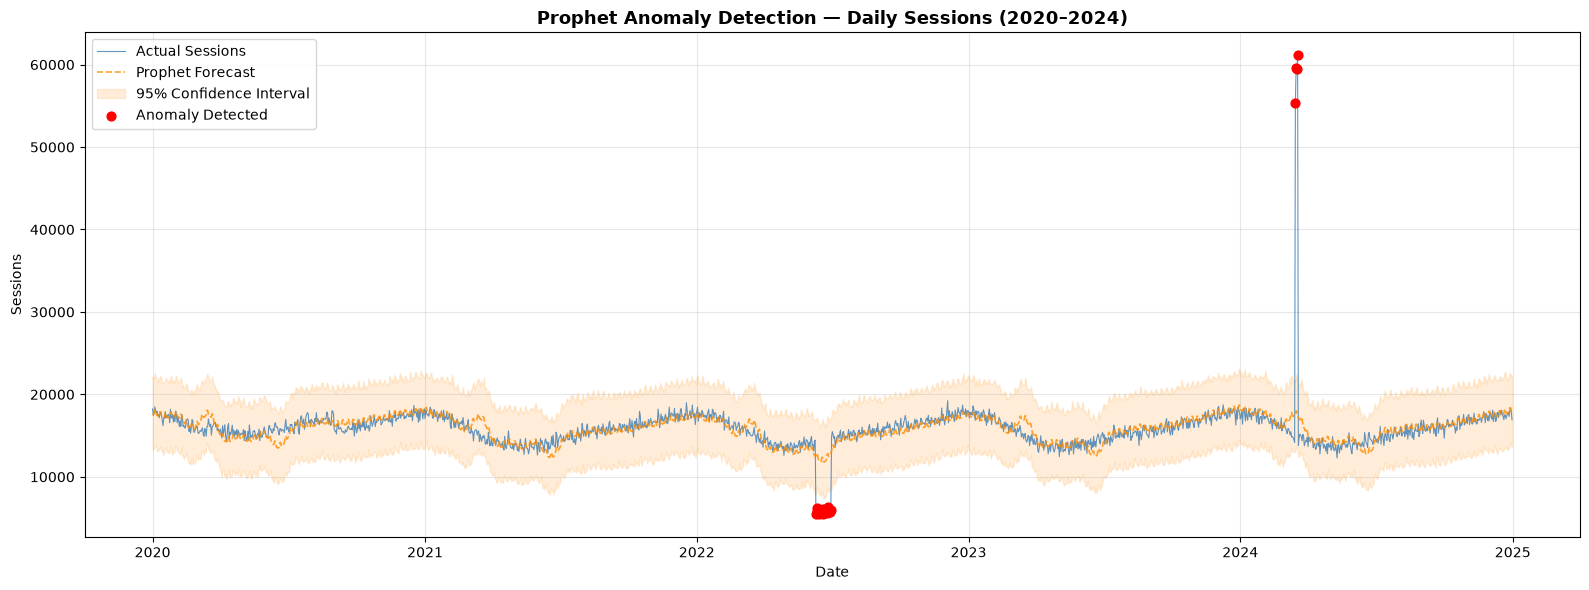

In [6]:
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(results['ds'], results['actual'],
        color='steelblue', linewidth=0.8, alpha=0.85, label='Actual Sessions')

ax.plot(results['ds'], results['yhat'],
        color='darkorange', linewidth=1.2, linestyle='--', alpha=0.8, label='Prophet Forecast')

ax.fill_between(results['ds'],
                results['yhat_lower'],
                results['yhat_upper'],
                color='darkorange', alpha=0.15, label='95% Confidence Interval')

ax.scatter(anomalies['ds'], anomalies['actual'],
           color='red', s=40, zorder=5, label='Anomaly Detected')

ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.set_title("Prophet Anomaly Detection — Daily Sessions (2020–2024)",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Sessions")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
import os

# Slice only the columns we need from the full anomalies DataFrame
# We don't need the boolean 'anomaly' flag column anymore — it's served its purpose
anomaly_report = anomalies[['ds', 'actual', 'yhat', 'yhat_lower', 'yhat_upper', 'deviation']].copy()

# Rename columns to human-readable names
# 'ds' and 'yhat' are Prophet's internal naming — fine for code, bad for a CSV a manager opens
anomaly_report.columns = ['date', 'actual_sessions', 'predicted_sessions',
                           'lower_bound', 'upper_bound', 'deviation']

# Calculate percentage deviation — how far off was reality from Prophet's expectation
# Formula: (actual - predicted) / predicted * 100
# Negative % = sessions were lower than expected (traffic drop)
# Positive % = sessions were higher than expected (traffic spike)
anomaly_report['deviation_pct'] = (
    (anomaly_report['actual_sessions'] - anomaly_report['predicted_sessions']) /
    anomaly_report['predicted_sessions'] * 100
).round(1)

# Label each anomaly as a human-readable type based on direction of deviation
# np.where is numpy's IF statement: np.where(condition, value_if_true, value_if_false)
# Negative deviation = actual fell below forecast = Traffic Drop
# Positive deviation = actual rose above forecast = Traffic Spike
anomaly_report['anomaly_type'] = np.where(
    anomaly_report['deviation'] < 0,
    'Traffic Drop',
    'Traffic Spike'
)

# Create the data/ folder if it doesn't exist yet
# exist_ok=True means: don't throw an error if it already exists, just continue
os.makedirs('../data', exist_ok=True)

# Save the anomaly report as a CSV
# index=False means don't write the row numbers (0, 1, 2...) as a column — cleaner output
anomaly_report.to_csv('../data/anomaly_report.csv', index=False)

print(f"Anomaly report saved — {len(anomaly_report)} rows")
print("\nPreview:")
print(anomaly_report.to_string(index=False))

Anomaly report saved — 25 rows

Preview:
      date  actual_sessions  predicted_sessions  lower_bound  upper_bound    deviation  deviation_pct  anomaly_type
2022-06-10             5518        12499.695063  7949.374628 16815.865786 -6981.695063          -55.9  Traffic Drop
2022-06-11             5867        12870.275291  8759.248423 17197.492176 -7003.275291          -54.4  Traffic Drop
2022-06-12             6183        12756.915993  8578.269699 16903.270185 -6573.915993          -51.5  Traffic Drop
2022-06-13             5649        12190.881872  8119.343757 16883.161095 -6541.881872          -53.7  Traffic Drop
2022-06-14             5490        11958.059901  7884.140166 16324.202234 -6468.059901          -54.1  Traffic Drop
2022-06-15             5826        11921.724957  7833.419448 15962.772094 -6095.724957          -51.1  Traffic Drop
2022-06-16             5950        11820.414869  7713.475533 16053.066508 -5870.414869          -49.7  Traffic Drop
2022-06-17             5754    

In [8]:
# Tell Prophet to extend the date range 90 days beyond the last date in our data
# periods=90 means generate 90 new future dates after 2024-12-31
# freq='D' means daily frequency — one row per day
future_90 = model.make_future_dataframe(periods=90, freq='D')

# Run the full dataset (historical + 90 future days) through the fitted model
# Prophet returns yhat, yhat_lower, yhat_upper for every single row
# Historical rows: these are the same predictions as before
# Future rows: these are genuine forward forecasts
forecast_90 = model.predict(future_90)

# Isolate only the 90 future rows — we don't need to re-examine the historical predictions
# The original data ended 2024-12-31, so we filter for anything strictly after that date
future_only = forecast_90[forecast_90['ds'] > '2024-12-31'].copy()

# Keep only the columns that matter for a forecast report
# ds = date, yhat = central forecast, lower/upper = confidence bounds
future_only = future_only[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

# Round all numeric columns to whole numbers — sessions are integers in reality
# A forecast of 17,432.7 sessions is false precision — round it
future_only['yhat'] = future_only['yhat'].round(0).astype(int)
future_only['yhat_lower'] = future_only['yhat_lower'].round(0).astype(int)
future_only['yhat_upper'] = future_only['yhat_upper'].round(0).astype(int)

# Rename columns to clean, readable names for the CSV output
future_only.columns = ['date', 'forecast_sessions', 'lower_bound', 'upper_bound']

# Save the forecast to disk — this is a separate deliverable from the anomaly report
future_only.to_csv('../data/forecast_report.csv', index=False)

print(f"Forecast report saved — {len(future_only)} rows")
print(f"\nForecast window: {future_only['date'].min()} to {future_only['date'].max()}")
print("\nFirst 7 days of forecast (Week 1, Jan 2025):")
print(future_only.head(7).to_string(index=False))

Forecast report saved — 90 rows

Forecast window: 2025-01-01 00:00:00 to 2025-03-31 00:00:00

First 7 days of forecast (Week 1, Jan 2025):
      date  forecast_sessions  lower_bound  upper_bound
2025-01-01              17785        13173        22211
2025-01-02              17728        13210        22149
2025-01-03              17836        13618        22156
2025-01-04              18291        14090        22867
2025-01-05              18252        13534        22791
2025-01-06              17748        13254        22234
2025-01-07              17564        13255        21904


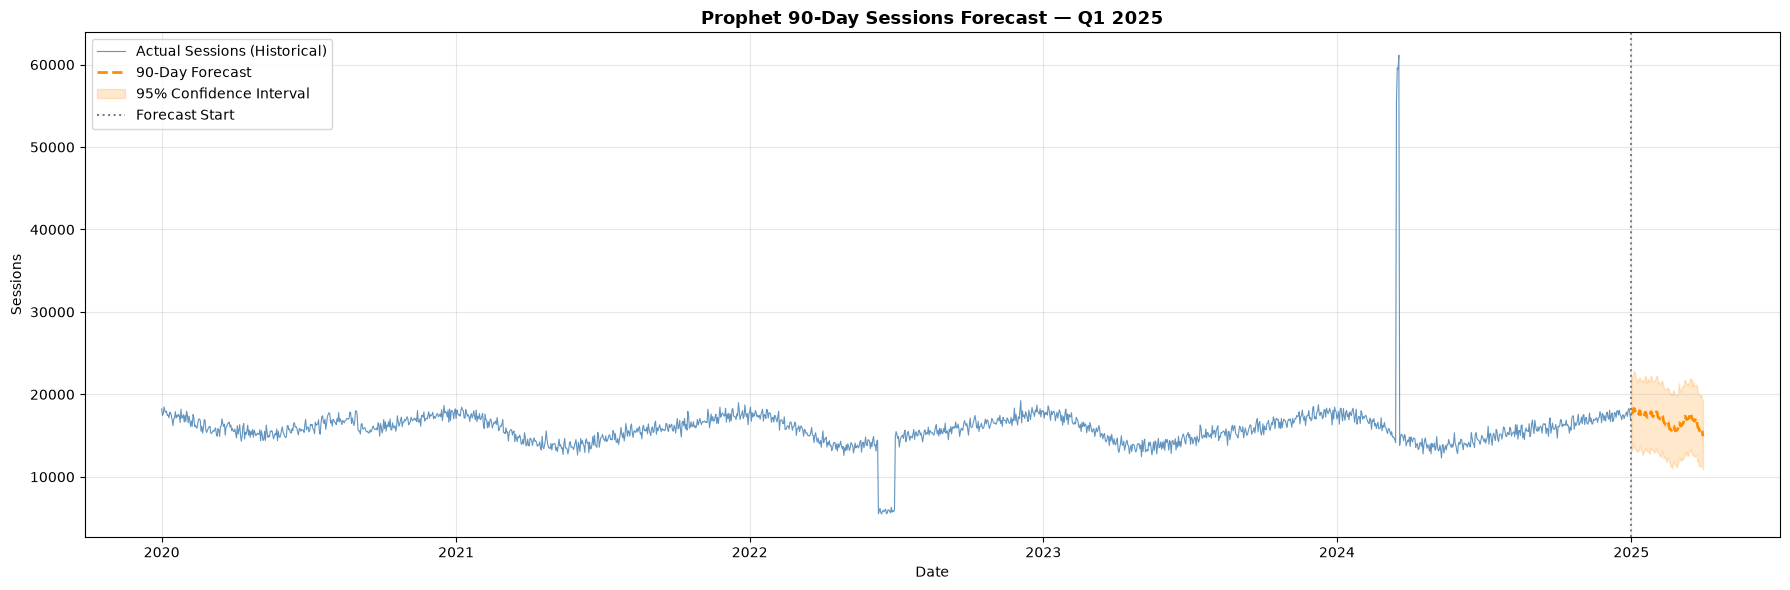

In [9]:
# --- Set up the figure ---
# We're creating one chart with a larger width to accommodate 5 years + 3 months
fig, ax = plt.subplots(figsize=(18, 6))

# --- Plot historical actual sessions ---
# This is the blue line showing real data from 2020-2024
# linewidth=0.8 keeps it fine so it doesn't overpower the forecast
ax.plot(df['date'], df['sessions'],
        color='steelblue', linewidth=0.8, alpha=0.85, label='Actual Sessions (Historical)')

# --- Plot the forecast line for future dates only ---
# Orange line extending beyond 2024 into Q1 2025
# linestyle='--' dashes it to visually signal "this is a prediction, not reality"
ax.plot(future_only['date'], future_only['forecast_sessions'],
        color='darkorange', linewidth=2, linestyle='--', label='90-Day Forecast')

# --- Shade the confidence band around the forecast ---
# This orange shaded region represents the 95% uncertainty interval
# It widens as we go further into the future — honest acknowledgement that uncertainty grows
ax.fill_between(future_only['date'],
                future_only['lower_bound'],
                future_only['upper_bound'],
                color='darkorange', alpha=0.2, label='95% Confidence Interval')

# --- Add a vertical line marking where history ends and forecast begins ---
# This is a critical visual separator — makes the chart immediately readable
# Without this line a viewer might not know where real data ends
ax.axvline(x=pd.Timestamp('2024-12-31'),
           color='gray', linestyle=':', linewidth=1.5, label='Forecast Start')

# --- Format the x-axis to show clean year labels ---
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# --- Labels, title, grid ---
ax.set_title("Prophet 90-Day Sessions Forecast — Q1 2025",
             fontsize=13, fontweight='bold')
ax.set_xlabel("Date")
ax.set_ylabel("Sessions")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# ── Final summary — confirms everything the notebook produced ──────────────────

# Count anomalies by type for the summary
# value_counts() tallies how many rows have each unique value in anomaly_type
drop_count = len(anomaly_report[anomaly_report['anomaly_type'] == 'Traffic Drop'])
spike_count = len(anomaly_report[anomaly_report['anomaly_type'] == 'Traffic Spike'])

# Calculate the average percentage deviation for each anomaly type
# This gives a single headline number that summarises severity
avg_drop_pct = anomaly_report[
    anomaly_report['anomaly_type'] == 'Traffic Drop']['deviation_pct'].mean().round(1)
avg_spike_pct = anomaly_report[
    anomaly_report['anomaly_type'] == 'Traffic Spike']['deviation_pct'].mean().round(1)

print("=" * 55)
print("   NOTEBOOK 03 — COMPLETE")
print("=" * 55)

print(f"\n ANOMALY DETECTION SUMMARY")
print(f"  Total days analysed   : {len(results):,}")
print(f"  Anomalies detected    : {len(anomaly_report)}")
print(f"  Traffic drops         : {drop_count} days (avg {avg_drop_pct}% deviation)")
print(f"  Traffic spikes        : {spike_count} days (avg {avg_spike_pct}% deviation)")

print(f"\n ANOMALY WINDOWS")
print(f"  Jun 10–30 2022  — Organic traffic drop (~55% below forecast)")
print(f"  Mar 15–18 2024  — Bot traffic spike (~230% above forecast)")

print(f"\n FORECASTING SUMMARY")
print(f"  Forecast window       : Q1 2025 (90 days)")
print(f"  Avg forecast sessions : {future_only['forecast_sessions'].mean():,.0f} per day")
print(f"  Forecast range        : {future_only['lower_bound'].min():,} – {future_only['upper_bound'].max():,}")

print(f"\n FILES SAVED")
print(f"  data/anomaly_report.csv   — {len(anomaly_report)} anomaly rows")
print(f"  data/forecast_report.csv  — {len(future_only)} forecast rows")

   NOTEBOOK 03 — COMPLETE

 ANOMALY DETECTION SUMMARY
  Total days analysed   : 1,827
  Anomalies detected    : 25
  Traffic drops         : 21 days (avg -52.5% deviation)
  Traffic spikes        : 4 days (avg 232.2% deviation)

 ANOMALY WINDOWS
  Jun 10–30 2022  — Organic traffic drop (~55% below forecast)
  Mar 15–18 2024  — Bot traffic spike (~230% above forecast)

 FORECASTING SUMMARY
  Forecast window       : Q1 2025 (90 days)
  Avg forecast sessions : 16,894 per day
  Forecast range        : 10,886 – 22,867

 FILES SAVED
  data/anomaly_report.csv   — 25 anomaly rows
  data/forecast_report.csv  — 90 forecast rows
